<div style="
    border: 3px solid #301CA0;
    background: linear-gradient(135deg, #F29AAE, #FDACAC, #FFCDC9);
    padding: 22px;
    border-radius: 14px;
    text-align: center;
    box-shadow: 0 0 18px rgba(249, 115, 22, 0.4);
">
    <h1 style="
        color: #301CA0;
        margin: 0;
        font-weight: 600;
        letter-spacing: 1px;
    ">
        Chest X-Ray Classification
    </h1>
    <p style="
        color: #301CA0;
        margin-top: 8px;
        font-size: 15px;
    ">
        Using CNN
    </p>
</div>


<div style="
    border: 2px solid #FD7979;
    background: linear-gradient(135deg, #FFCDC9, #BB8ED0);
    padding: 12px 18px;
    border-radius: 10px;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    box-shadow: 0 0 10px rgba(124, 131, 253, 0.3);
">
    <strong style="
        color:#301CA0;
        font-size: 20px;
        letter-spacing: 0.5px;
    ">
     import libraires & Reading Data 
    </strong>
    
</div>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Input,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import Recall
from PIL import Image
import os
import cv2
import random
import json
import seaborn as sns
from sklearn.metrics import confusion_matrix,classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

2025-12-17 03:45:59.755553: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765943159.779727    4550 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765943159.789659    4550 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
base_dir="/kaggle/input/chest-xray-pneumonia/chest_xray"
train_dir=os.path.join(base_dir,"train")
val_dir=os.path.join(base_dir,"val")
test_dir=os.path.join(base_dir,"test")

In [3]:
class_names=os.listdir(train_dir)

In [4]:
class_to_index={name:i for i,name in enumerate(class_names)}

In [5]:
class_to_index

{'PNEUMONIA': 0, 'NORMAL': 1}

In [6]:
print(train_dir)
print(val_dir)
print(test_dir)

/kaggle/input/chest-xray-pneumonia/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/test


In [7]:
def load_data(data_dir,image_size=(224,224)):
    images=[]
    labels=[]

    for label_name in os.listdir(data_dir):
        label_path=os.path.join(data_dir,label_name)
        if not os.path.isdir(label_path):
            continue

        for img_file in os.listdir(label_path):
            img_path=os.path.join(label_path,img_file)
            img=cv2.imread(img_path)
            if img is None:
                continue

            img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
            img=cv2.resize(img,image_size)
            images.append(img)
            labels.append(class_to_index[label_name])
    images = np.array(images) / 255.0 
    labels = np.array(labels)
    return images, labels

In [8]:
train_img,train_label=load_data(train_dir)
val_img,val_label=load_data(val_dir)
test_img,test_label=load_data(test_dir)

In [9]:
print("Train:", train_img.shape, train_label.shape)
print("Validation:", val_img.shape, val_label.shape)
print("Test:", test_img.shape, test_label.shape)

Train: (5216, 224, 224, 3) (5216,)
Validation: (16, 224, 224, 3) (16,)
Test: (624, 224, 224, 3) (624,)


<div style="
    border: 2px solid #FD7979;
    background: linear-gradient(135deg, #FFCDC9, #BB8ED0);
    padding: 12px 18px;
    border-radius: 10px;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    box-shadow: 0 0 10px rgba(124, 131, 253, 0.3);
">
    <strong style="
        color:#301CA0;
        font-size: 20px;
        letter-spacing: 0.5px;
    ">
     Check Label Balancing 
    </strong>
    
</div>


In [10]:
_,count=np.unique(train_label,return_counts=True)

<Axes: >

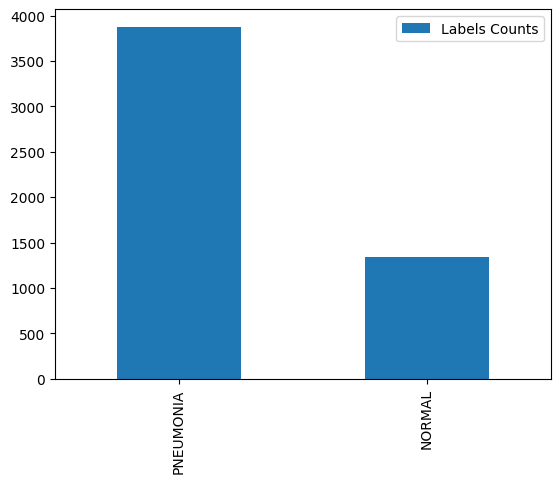

In [11]:
pd.DataFrame({'Labels Counts':count},index=class_to_index).plot.bar()

([<matplotlib.patches.Wedge at 0x7a925cfece10>,
 [Text(-0.7602920671935068, 0.7949565853319438, 'PNEUMONIA'),
  Text(0.7602920671935068, -0.7949565853319439, 'NORMAL')],
 [Text(-0.41470476392373096, 0.43361268290833294, '74.3%'),
  Text(0.41470476392373096, -0.43361268290833305, '25.7%')])

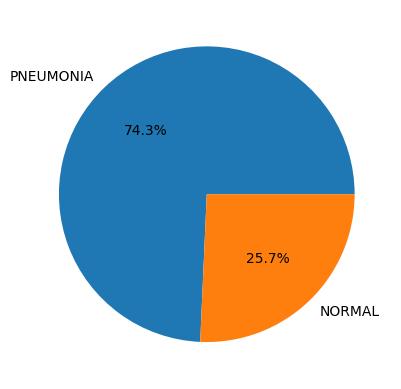

In [12]:
plt.pie(count,explode=(0,0),labels=class_to_index,autopct="%1.1f%%")

In [13]:
index_to_class = {v: k for k, v in class_to_index.items()}
index_to_class

{0: 'PNEUMONIA', 1: 'NORMAL'}

<div style="
    border: 2px solid #FD7979;
    background: linear-gradient(135deg, #FFCDC9, #BB8ED0);
    padding: 12px 18px;
    border-radius: 10px;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    box-shadow: 0 0 10px rgba(124, 131, 253, 0.3);
">
    <strong style="
        color:#301CA0;
        font-size: 20px;
        letter-spacing: 0.5px;
    ">
     Show Data Sample
    </strong>
    
</div>


In [14]:
def display_images(images,labels,n=10):
    for i in range(n):
        idx=random.randint(0,len(images)-1)
        plt.imshow(images[idx])
        plt.title(f"Label:{index_to_class[labels[idx]]}")
        plt.axis('off')
        plt.show()

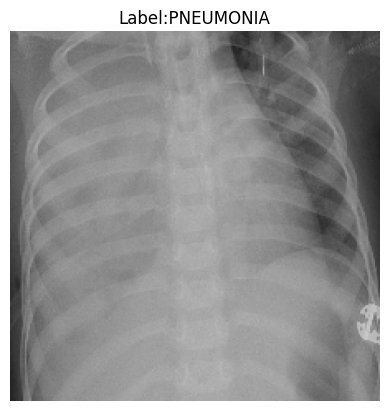

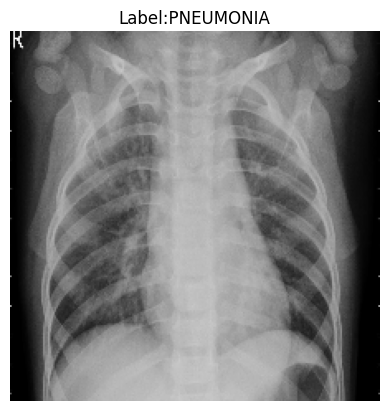

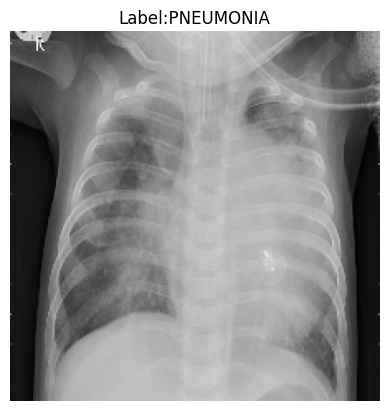

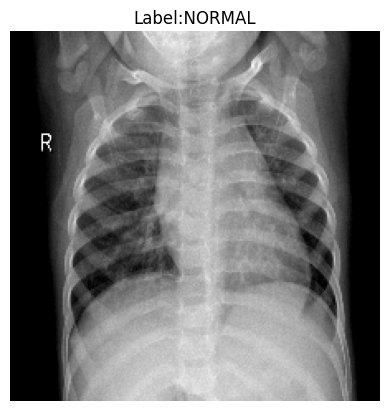

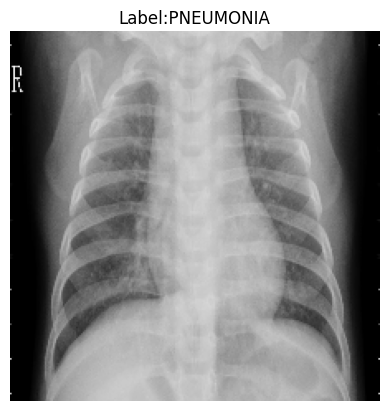

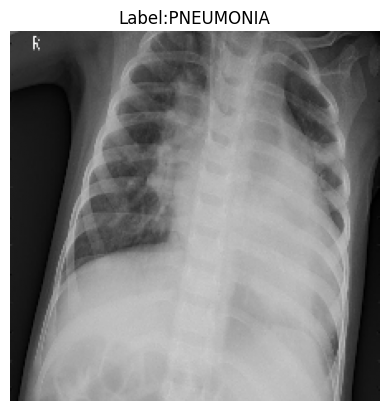

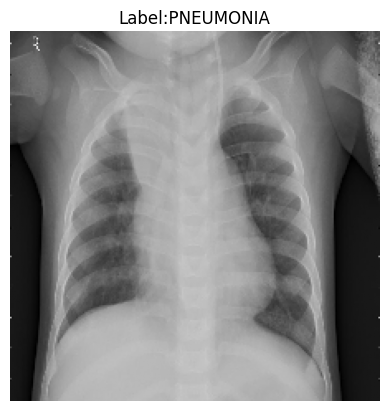

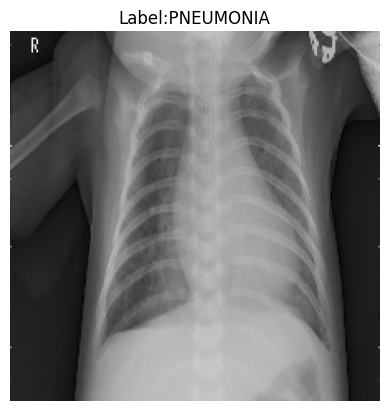

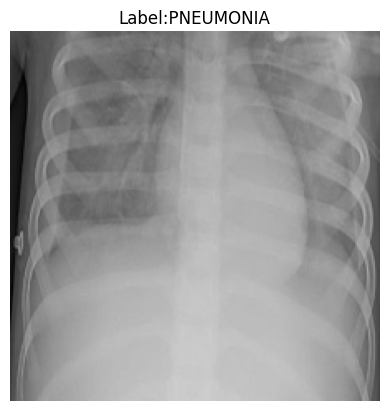

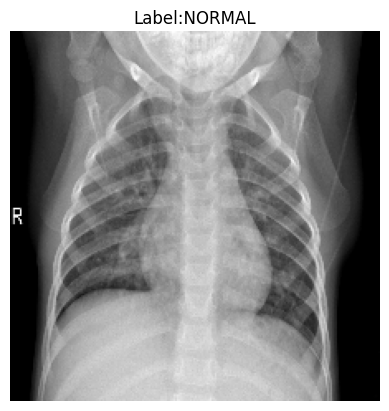

In [15]:
display_images(train_img,train_label,10)

<div style="
    border: 2px solid #FD7979;
    background: linear-gradient(135deg, #FFCDC9, #BB8ED0);
    padding: 12px 18px;
    border-radius: 10px;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    box-shadow: 0 0 10px rgba(124, 131, 253, 0.3);
">
    <strong style="
        color:#301CA0;
        font-size: 20px;
        letter-spacing: 0.5px;
    ">
     Handle Data Imbalanced 
    </strong>
    
</div>


In [16]:
indices=np.arange(len(train_img))
np.random.shuffle(indices)
train_img=train_img[indices]
train_label=train_label[indices]

In [17]:
datagen=ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
train_generator=datagen.flow(
    train_img,
    train_label,
    batch_size=32,
    shuffle=True
    
)

In [18]:
class_weights=compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_label),
    y=train_label)


In [19]:
class_weights=dict(enumerate(class_weights))
print(class_weights)

{0: 0.6730322580645162, 1: 1.9448173005219984}


<div style="
    border: 2px solid #FD7979;
    background: linear-gradient(135deg, #FFCDC9, #BB8ED0);
    padding: 12px 18px;
    border-radius: 10px;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    box-shadow: 0 0 10px rgba(124, 131, 253, 0.3);
">
    <strong style="
        color:#301CA0;
        font-size: 20px;
        letter-spacing: 0.5px;
    ">
     Built,Compile & Fit CNN Model
    </strong>
    
</div>


In [20]:
CNN=Sequential([
    Input(shape=(224,224,3)),
    
    Conv2D(32,3,activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64,3,activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    


    Flatten(),
    
    Dense(64,activation='relu'),
    Dropout(0,5),
    
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
    
])

I0000 00:00:1765943238.835490    4550 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765943238.836061    4550 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [21]:
CNN.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy',Recall()]
           )

In [22]:
history=CNN.fit(
    train_generator,
    steps_per_epoch=len(train_img)//32,
    validation_data=(val_img,val_label),
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20


I0000 00:00:1765943242.313116    4609 service.cc:148] XLA service 0x7a90b800c4e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765943242.313158    4609 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765943242.313161    4609 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765943242.561728    4609 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/163 ━━━━━━━━━━━━━━━━━━━━ 15:50 6s/step - accuracy: 0.7500 - loss: 0.6881 - recall: 0.0000e+00

I0000 00:00:1765943246.064773    4609 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 309ms/step - accuracy: 0.6968 - loss: 0.7765 - recall: 0.6400 - val_accuracy: 0.8750 - val_loss: 0.4396 - val_recall: 0.8750
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 301ms/step - accuracy: 0.8758 - loss: 0.2875 - recall: 0.9141 - val_accuracy: 0.7500 - val_loss: 0.4652 - val_recall: 0.6250
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 303ms/step - accuracy: 0.8960 - loss: 0.2437 - recall: 0.9300 - val_accuracy: 0.8750 - val_loss: 0.3264 - val_recall: 0.8750
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 304ms/step - accuracy: 0.8979 - loss: 0.2370 - recall: 0.9300 - val_accuracy: 0.8125 - val_loss: 0.3095 - val_recall: 0.7500
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 306ms/step - accuracy: 0.9057 - loss: 0.2190 - recall: 0.9382 - val_accuracy: 0.9375 - val_loss: 0.3090 - val_recall: 1.0000
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 305ms/step - accuracy: 0.9105 - loss: 0.2267 - recall: 0.9357 - val_accuracy: 0.9375 - val_loss: 0.2186 - val_recall: 0.87

<div style="
    border: 2px solid #FD7979;
    background: linear-gradient(135deg, #FFCDC9, #BB8ED0);
    padding: 12px 18px;
    border-radius: 10px;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    box-shadow: 0 0 10px rgba(124, 131, 253, 0.3);
">
    <strong style="
        color:#301CA0;
        font-size: 20px;
        letter-spacing: 0.5px;
    ">
    Visualize Model Performance With Train & Validation Data 
    </strong>
    
</div>


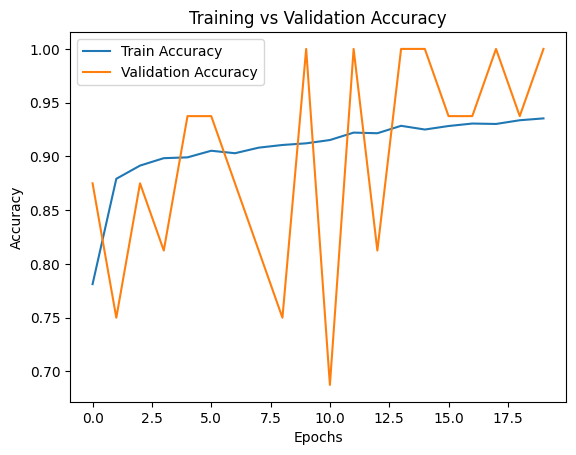

In [23]:
plt.figure()
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

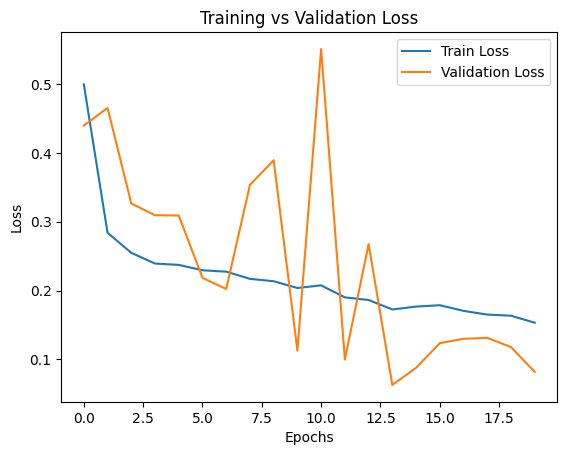

In [24]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


In [25]:
print(history.history.keys())


dict_keys(['accuracy', 'loss', 'recall', 'val_accuracy', 'val_loss', 'val_recall'])


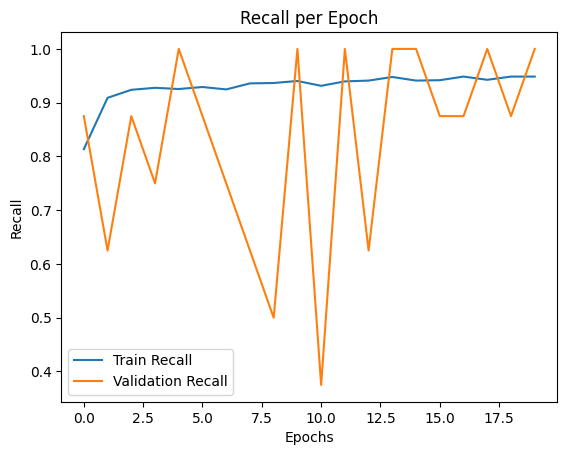

In [26]:
plt.figure()
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.title('Recall per Epoch')
plt.show()


<div style="
    border: 2px solid #FD7979;
    background: linear-gradient(135deg, #FFCDC9, #BB8ED0);
    padding: 12px 18px;
    border-radius: 10px;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    box-shadow: 0 0 10px rgba(124, 131, 253, 0.3);
">
    <strong style="
        color:#301CA0;
        font-size: 20px;
        letter-spacing: 0.5px;
    ">
        Visualize Predicted & True Label For Random Images 
    </strong>
    
</div>


In [27]:
y_pred=CNN.predict(test_img)
y_pred_index=(y_pred>=0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [28]:
index_to_class={v:k for k,v in class_to_index.items()}

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


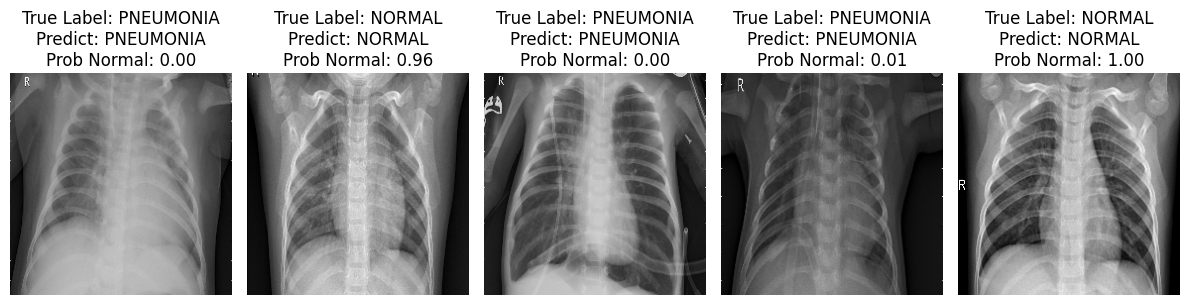

In [29]:

def show_random_images_predictions(test_images, test_labels, model, num_images=4, threshold=0.5):
   
    plt.figure(figsize=(12, 12))
    
    for i in range(num_images):
        idx = np.random.randint(len(test_images))
        img = test_images[idx]
        true_label_index = test_labels[idx]
        
        
        img_input = np.expand_dims(img, axis=0)
        prob_normal = model.predict(img_input)[0][0]
        
        pred_index = 1 if prob_normal >= threshold else 0
        pred_label = index_to_class[pred_index]
        true_label = index_to_class[true_label_index]
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(f"True Label: {true_label}\nPredict: {pred_label}\nProb Normal: {prob_normal:.2f}")
    
    plt.tight_layout()
    plt.show()

show_random_images_predictions(test_img, test_label, CNN, num_images=5)


<div style="
    border: 2px solid #FD7979;
    background: linear-gradient(135deg, #FFCDC9, #BB8ED0);
    padding: 12px 18px;
    border-radius: 10px;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    box-shadow: 0 0 10px rgba(124, 131, 253, 0.3);
">
    <strong style="
        color:#301CA0;
        font-size: 20px;
        letter-spacing: 0.5px;
    ">
         Check Overfitting & Model Performance
    </strong>
    
</div>


In [30]:
loss_test,accuracy_test,recall_test=CNN.evaluate(test_img,test_label)
print("*"*60)
print("Test Data")
print(f"Loss For Test Data:{loss_test}")
print(f"Accuracy For Test Data:{accuracy_test}")
print(f"Recall For Test Data:{recall_test}")
print("*"*60)
print("Train Data")
loss_train, accuracy_train, recall_train = CNN.evaluate(train_img, train_label)
print("Train Loss:", loss_train)
print("Train Accuracy:", accuracy_train)
print("Train Recall:", recall_train)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9466 - loss: 0.1577 - recall: 0.3397
************************************************************
Test Data
Loss For Test Data:0.2892243564128876
Accuracy For Test Data:0.9006410241127014
Recall For Test Data:0.7948718070983887
************************************************************
Train Data
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9365 - loss: 0.1607 - recall: 0.9927
Train Loss: 0.15654408931732178
Train Accuracy: 0.939225435256958
Train Recall: 0.9940342903137207


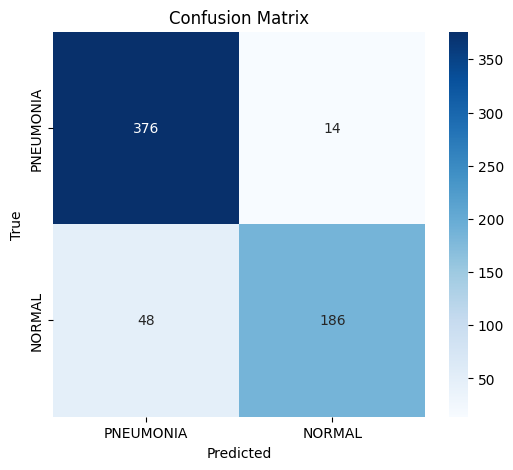

In [31]:
cm=confusion_matrix(test_label,y_pred_index)
classes = ['PNEUMONIA', 'NORMAL']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

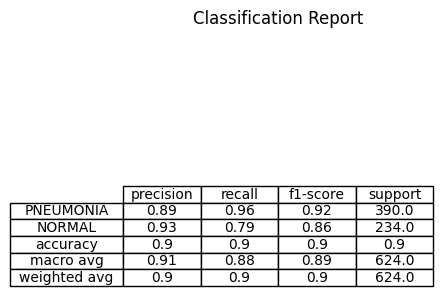

In [35]:

report = classification_report(test_label, y_pred_index, target_names=['PNEUMONIA','NORMAL'], output_dict=True)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(4,2))
plt.axis('off')
plt.title('Classification Report')
plt.table(cellText=np.round(report_df.values, 2),
          colLabels=report_df.columns,
          rowLabels=report_df.index,
          cellLoc='center',
          rowLoc='center')
plt.show()

<div style="
    border: 2px solid #FD7979;
    background: linear-gradient(135deg, #FFCDC9, #BB8ED0);
    padding: 12px 18px;
    border-radius: 10px;
    display: inline-flex;
    align-items: center;
    gap: 8px;
    box-shadow: 0 0 10px rgba(124, 131, 253, 0.3);
">
    <strong style="
        color:#301CA0;
        font-size: 20px;
        letter-spacing: 0.5px;
    ">
        Save Model & Classes Map
    </strong>
    
</div>


In [36]:
CNN.save("CNN.keras")

In [38]:

with open("chest X-Ray Classes.json",'w') as f:
    json.dump(class_to_index,f)